In [3]:
SELECTED_PHONEMES = ['s', 'ih', 'aa', 'iy', 'n']   # 5 classes, no 'sil'
TARGET_CLUSTERS   = len(SELECTED_PHONEMES)   
RANDOM_SEED = 42

In [4]:
import os, json, warnings
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplconfig')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
    v_measure_score,
)

try:
    import hdbscan as hdbscan_lib
    HDBSCAN_AVAILABLE = True
    print(f'hdbscan available')
except ImportError:
    HDBSCAN_AVAILABLE = False
    print('WARNING: hdbscan not installed. Run: pip install hdbscan')

plt.style.use('ggplot')
rng = np.random.default_rng(RANDOM_SEED)
print('Imports OK.')

hdbscan available
Imports OK.


Utterances : 4,620
Sample ID  : FEXM0_SX291
Keys       : ['features', 'feat_shape', 'phn_transcript', 'phn_wise_segment', 'segment_boundary', 'no_segments']
Feature dim: (349, 12)  (T frames x 12 MFCC)
Transcript : [['sil', 0, 13], ['dh', 13, 16], ['iy', 16, 30]] ...
Counting frame-level phoneme distribution across all utterances ...
Total labeled frames : 1,419,678
Unique phones        : 39


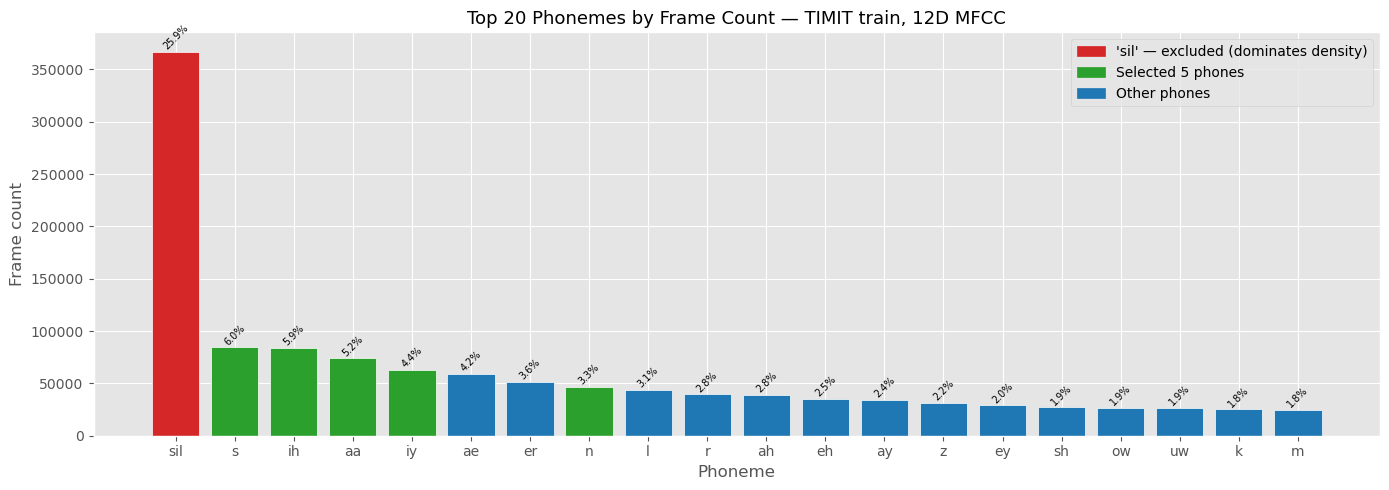

In [5]:
DATA_PATH         = 'train_dim12.json'

with open(DATA_PATH, 'r') as f:
    dataset = json.load(f)

utt_ids = list(dataset.keys())
sample  = dataset[utt_ids[0]]
print(f'Utterances : {len(utt_ids):,}')
print(f'Sample ID  : {utt_ids[0]}')
print(f'Keys       : {list(sample.keys())}')
print(f'Feature dim: {np.asarray(sample["features"]).shape}  (T frames x 12 MFCC)')
print(f'Transcript : {sample["phn_transcript"][:3]} ...')

def expand_frame_labels(utt):
   
    T = len(utt['features'])
    frame_labels = np.full(T, 'unlabeled', dtype=object)
    transcript = utt['phn_transcript']
    for seg_idx, (label, start, end) in enumerate(transcript):
        start = max(0, min(int(start), T))
        end   = max(start, min(int(end), T))
        if seg_idx == len(transcript) - 1 and end == T - 1:
            end = T
        if end > start:
            frame_labels[start:end] = label
    return frame_labels


print('Counting frame-level phoneme distribution across all utterances ...')
phone_frame_counts = Counter()
for utt in dataset.values():
    phone_frame_counts.update(expand_frame_labels(utt))
phone_frame_counts.pop('unlabeled', None)

total_frames = sum(phone_frame_counts.values())
print(f'Total labeled frames : {total_frames:,}')
print(f'Unique phones        : {len(phone_frame_counts)}')

df_counts = pd.DataFrame(
    phone_frame_counts.most_common(),
    columns=['phone', 'frame_count']
)
df_counts['pct'] = (df_counts['frame_count'] / total_frames * 100).round(2)

top20 = df_counts.head(20).copy()
colors = [
    '#d62728' if p == 'sil'
    else '#2ca02c' if p in SELECTED_PHONEMES
    else '#1f77b4'
    for p in top20['phone']
]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(top20['phone'], top20['frame_count'], color=colors, edgecolor='white')

legend_items = [
    mpatches.Patch(color='#d62728', label="'sil' — excluded (dominates density)"),
    mpatches.Patch(color='#2ca02c', label='Selected 5 phones'),
    mpatches.Patch(color='#1f77b4', label='Other phones'),
]
ax.legend(handles=legend_items, fontsize=10)
ax.set_xlabel('Phoneme', fontsize=12)
ax.set_ylabel('Frame count', fontsize=12)
ax.set_title('Top 20 Phonemes by Frame Count — TIMIT train, 12D MFCC', fontsize=13)
for bar, row in zip(bars, top20.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{row.pct:.1f}%', ha='center', va='bottom', fontsize=7, rotation=45)
plt.tight_layout()
plt.show()


In [6]:
def build_frame_dataset_5class(dataset, selected_phonemes, drop_unlabeled=True):
    
    phone_set = set(selected_phonemes)
    X_parts, y_parts, meta_rows = [], [], []
    for utt_id, utt in dataset.items():
        feats = np.asarray(utt['features'], dtype=np.float32)
        frame_labels = expand_frame_labels(utt)
        for t, lbl in enumerate(frame_labels):
            if lbl not in phone_set:
                continue
            X_parts.append(feats[t])
            y_parts.append(lbl)
            meta_rows.append({'utt_id': utt_id, 'frame_idx': t, 'phoneme': lbl})
    X    = np.stack(X_parts)
    y    = np.array(y_parts, dtype=object)
    meta = pd.DataFrame(meta_rows)
    return X, y, meta


print('Building 5-class frame dataset (iterates full train set) ...')
X_full, y_full, meta_full = build_frame_dataset_5class(dataset, SELECTED_PHONEMES)
print(f'Total frames (5 classes): {len(X_full):,}')
cnt_full = Counter(y_full)
df_balance = pd.DataFrame(
    [(p, cnt_full[p], cnt_full[p]/len(y_full)*100) for p in SELECTED_PHONEMES],
    columns=['phone', 'n_frames', 'pct']
)
print('\nClass balance:')
display(df_balance)

Building 5-class frame dataset (iterates full train set) ...
Total frames (5 classes): 352,543

Class balance:


,phone,n_frames,pct
0,s,84491,23.966154
1,ih,84270,23.903467
2,aa,73885,20.957727
3,iy,62901,17.842079
4,n,46996,13.330572


In [13]:
# stratified subset builder

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter
import matplotlib.pyplot as plt

def build_stratified_subset(
    X_full, y_full, meta_full,
    selected_phonemes,
    subset_size,
    random_seed=0,
    plot_dist=True
):
    rng = np.random.default_rng(random_seed)

    target_clusters = len(selected_phonemes)
    frames_per_class = subset_size // target_clusters

    idx_sub = []
    for phone in selected_phonemes:
        idx_phone = np.where(y_full == phone)[0]
        chosen = rng.choice(
            idx_phone,
            size=min(frames_per_class, len(idx_phone)),
            replace=False
        )
        idx_sub.append(chosen)

    idx_sub = np.concatenate(idx_sub)
    rng.shuffle(idx_sub)

    X_sub = X_full[idx_sub]
    y_sub = y_full[idx_sub]
    meta_sub = meta_full.iloc[idx_sub].reset_index(drop=True)

    print(f'Subset: {len(X_sub):,} frames ({frames_per_class} per class)')

    # scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sub)

    print(f'Mean (scaled): {X_scaled.mean(axis=0).round(3)}')
    print(f'Std  (scaled): {X_scaled.std(axis=0).round(3)}')

    # optional distribution plot
    if plot_dist:
        cnt = Counter(y_sub)
        cmap = plt.cm.tab10(np.linspace(0, 0.9, target_clusters))

        plt.figure(figsize=(5,4))
        plt.bar(
            selected_phonemes,
            [cnt[p] for p in selected_phonemes],
            color=cmap,
            edgecolor='white'
        )
        plt.title(f'Subset class balance (N={len(X_sub):,})')
        plt.xlabel('Phoneme')
        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()

    return X_scaled, y_sub, meta_sub

In [14]:
from sklearn.manifold import TSNE


def compute_tsne_embedding(
    X_scaled,
    tsne_size,
    seed=0,
    perplexity=30,
    init='pca'
):
    rng = np.random.default_rng(seed)

    n = min(tsne_size, len(X_scaled))
    vis_idx = np.sort(rng.choice(len(X_scaled), size=n, replace=False))

    # safe perplexity
    perp = float(min(perplexity, max(5, n // 100)))

    tsne = TSNE(
        n_components=2,
        init=init,
        learning_rate='auto',
        perplexity=perp,
        random_state=seed,
        n_jobs=-1
    )

    embedding = tsne.fit_transform(X_scaled[vis_idx])

    print(f't-SNE computed: {embedding.shape}, perplexity={perp}')

    return embedding, vis_idx

In [15]:
def plot_tsne_ground_truth(
    embedding,
    y_vis,
    selected_phonemes,
    phone_colors=None,
    title=None
):
    if phone_colors is None:
        phone_colors = {
            p: plt.cm.tab10(i / 9)
            for i, p in enumerate(selected_phonemes)
        }

    plt.figure(figsize=(8, 6))

    for phone in selected_phonemes:
        mask = y_vis == phone
        plt.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            c=[phone_colors[phone]],
            label=phone,
            s=8,
            alpha=0.6,
            linewidths=0
        )

    plt.legend(title='Phone', markerscale=2)
    plt.title(title or 't-SNE (Ground Truth)')
    plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.show()

In [25]:
def plot_tsne_clusters(
    embedding,
    cluster_vis,
    y_vis,
    selected_phonemes,
    method_name,
    axes=None
):
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax_gt, ax_pred = axes

    # ---------- LEFT: GROUND TRUTH ----------
    phone_colors = {
        p: plt.cm.tab10(i / max(len(selected_phonemes)-1, 1))
        for i, p in enumerate(selected_phonemes)
    }

    for phone in selected_phonemes:
        mask = (y_vis == phone)
        ax_gt.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            c=[phone_colors[phone]],
            s=6,
            alpha=0.6,
            linewidths=0,
            label=phone
        )

    ax_gt.set_title('Ground Truth')
    ax_gt.set_xticks([]); ax_gt.set_yticks([])
    ax_gt.legend(fontsize=8, markerscale=2)

    # ---------- RIGHT: CLUSTERS ----------
    unique_clusters = sorted(set(cluster_vis))
    n_clusters = sum(1 for c in unique_clusters if c >= 0)
    noise_frac = (cluster_vis == -1).mean()

    # draw noise first
    noise_mask = (cluster_vis == -1)
    if noise_mask.any():
        ax_pred.scatter(
            embedding[noise_mask, 0],
            embedding[noise_mask, 1],
            c='#999999',
            s=5,
            alpha=0.3,
            linewidths=0,
            label='noise'
        )

    cmap = plt.cm.tab10
    cluster_ids = [c for c in unique_clusters if c >= 0]

    for i, cid in enumerate(cluster_ids):
        mask = (cluster_vis == cid)
        ax_pred.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            c=[cmap(i / max(len(cluster_ids)-1, 1))],
            s=10,
            alpha=0.8,
            linewidths=0,
            label=f'C{cid}'
        )

    ax_pred.set_title(
        f'{method_name}\nclusters={n_clusters}, coverage={1-noise_frac:.1%}'
    )
    ax_pred.set_xticks([]); ax_pred.set_yticks([])
    ax_pred.legend(fontsize=7, markerscale=1.5)

    plt.tight_layout()
    return axes

In [16]:
def run_tsne_experiment(
    X_full, y_full, meta_full,
    selected_phonemes,
    subset_size,
    tsne_size,
    random_seed=0
):
    X_scaled, y_sub, meta_sub = build_stratified_subset(
        X_full, y_full, meta_full,
        selected_phonemes,
        subset_size,
        random_seed
    )

    embedding, vis_idx = compute_tsne_embedding(
        X_scaled,
        tsne_size,
        seed=random_seed
    )

    y_vis = y_sub[vis_idx]

    plot_tsne_ground_truth(
        embedding,
        y_vis,
        selected_phonemes,
        title=f't-SNE | subset={subset_size}, tsne={tsne_size}'
    )

    return {
        "X_scaled": X_scaled,
        "y_sub": y_sub,
        "meta_sub": meta_sub,
        "embedding": embedding,
        "vis_idx": vis_idx,
        "y_vis": y_vis
    }

Subset: 20,000 frames (4000 per class)
Mean (scaled): [ 0.  0. -0. -0. -0. -0. -0. -0. -0.  0.  0. -0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


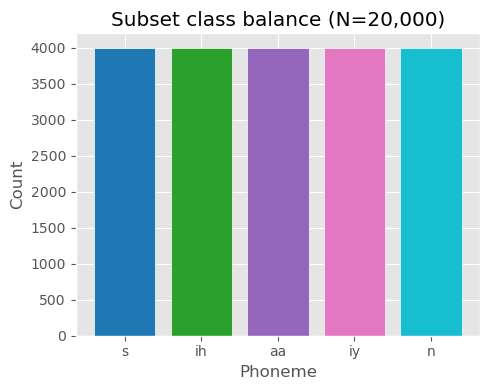

t-SNE computed: (5000, 2), perplexity=30.0


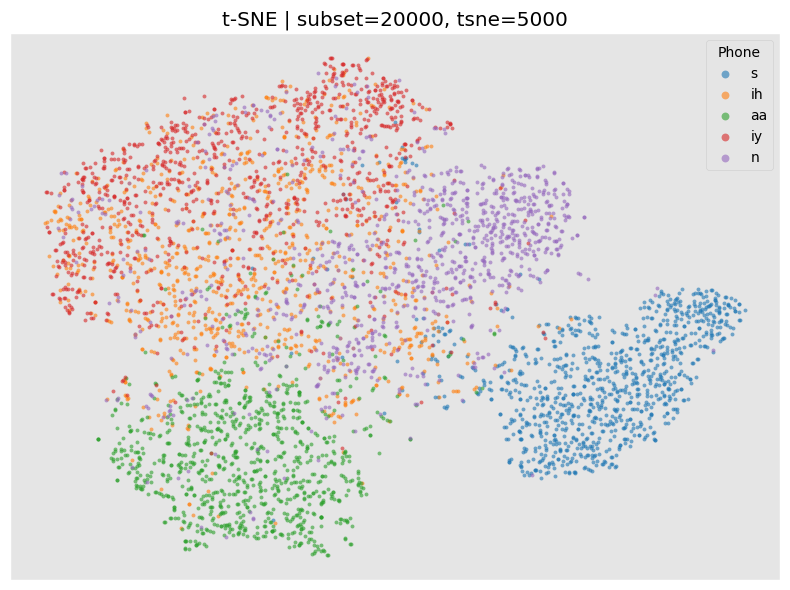

In [17]:
res = run_tsne_experiment(
    X_full, y_full, meta_full,
    SELECTED_PHONEMES,
    subset_size=20000,
    tsne_size=5000,
    random_seed=RANDOM_SEED
)

In [19]:
def plot_k_distance_curves(X_scaled, k_values=None, quantile_levels=None):
    
    if k_values is None:
        k_values = [4, 6, 10, 16]
    if quantile_levels is None:
        quantile_levels = [0.50, 0.75, 0.90, 0.95, 0.99]

    fig, ax = plt.subplots(figsize=(11, 5))
    rows = []
    for k in k_values:
        nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree', n_jobs=-1)
        nbrs.fit(X_scaled)
        dists, _ = nbrs.kneighbors(X_scaled)
        kth = np.sort(dists[:, k])
        ax.plot(kth, label=f'k={k}')
        row = {'k': k}
        for q in quantile_levels:
            row[f'q{int(q*100)}'] = round(float(np.quantile(kth, q)), 4)
        rows.append(row)

    ax.set_xlabel('Points sorted by k-th neighbor distance', fontsize=11)
    ax.set_ylabel('k-th Nearest Neighbor Distance', fontsize=11)
    ax.set_title('k-Distance Curves — elbow guides eps selection for DBSCAN', fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows).set_index('k')



===== SUBSET SIZE: 10000 =====
Subset: 10,000 frames (2000 per class)
Mean (scaled): [-0. -0.  0. -0. -0. -0.  0. -0.  0. -0.  0.  0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


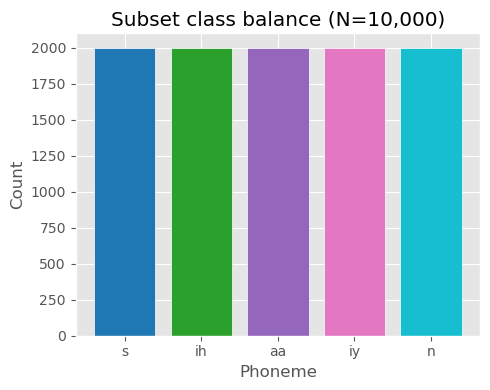

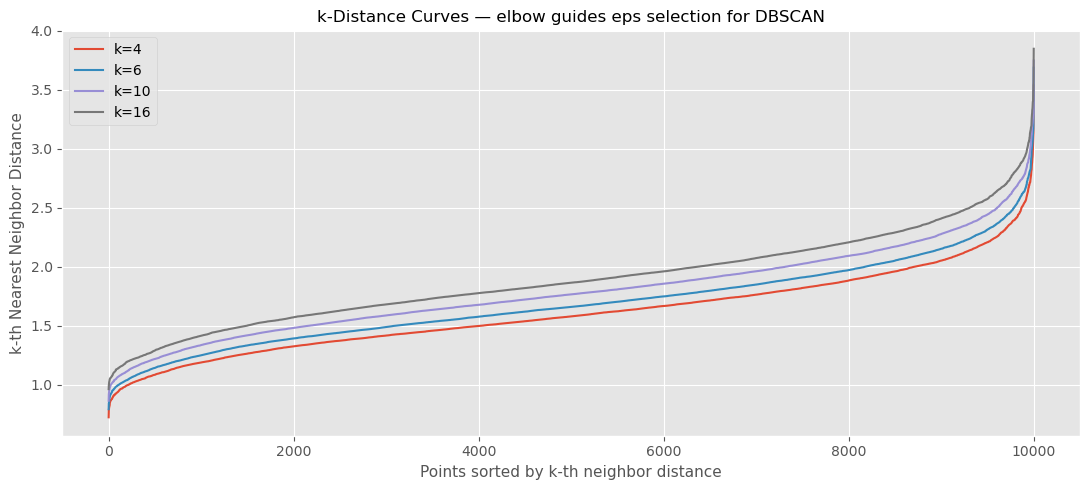

k-Distance quantile table:
       q50     q75     q90     q95     q99
k                                         
4   1.5774  1.8195  2.0511  2.2070  2.5433
6   1.6584  1.9085  2.1519  2.3148  2.6402
10  1.7647  2.0236  2.2764  2.4437  2.7815
16  1.8636  2.1346  2.4086  2.5737  2.9263

===== SUBSET SIZE: 20000 =====
Subset: 20,000 frames (4000 per class)
Mean (scaled): [ 0.  0. -0. -0. -0. -0. -0. -0. -0.  0.  0. -0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


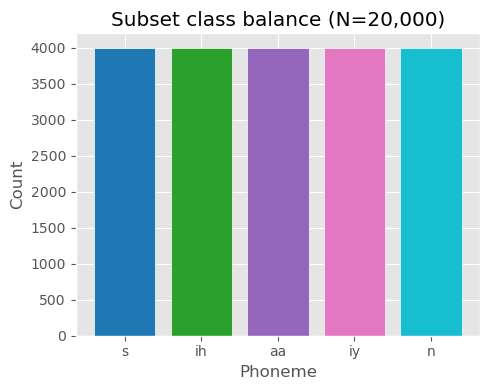

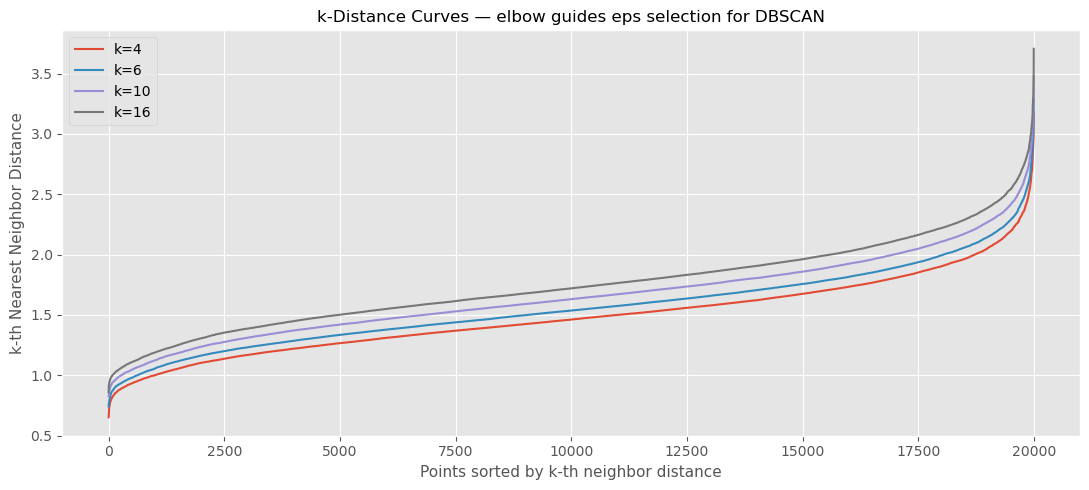

k-Distance quantile table:
       q50     q75     q90     q95     q99
k                                         
4   1.4618  1.6749  1.9027  2.0522  2.3711
6   1.5364  1.7566  1.9936  2.1453  2.4871
10  1.6297  1.8581  2.1072  2.2693  2.6238
16  1.7202  1.9617  2.2192  2.3867  2.7582

===== SUBSET SIZE: 50000 =====
Subset: 50,000 frames (10000 per class)
Mean (scaled): [-0. -0. -0. -0. -0.  0. -0.  0.  0.  0. -0.  0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


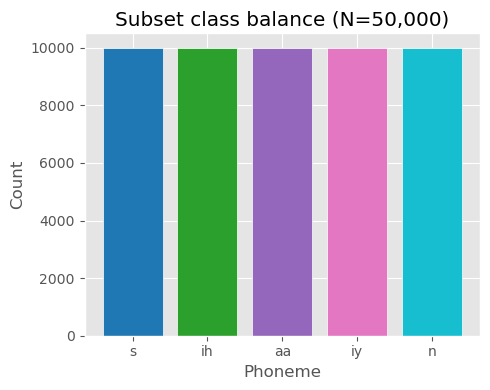

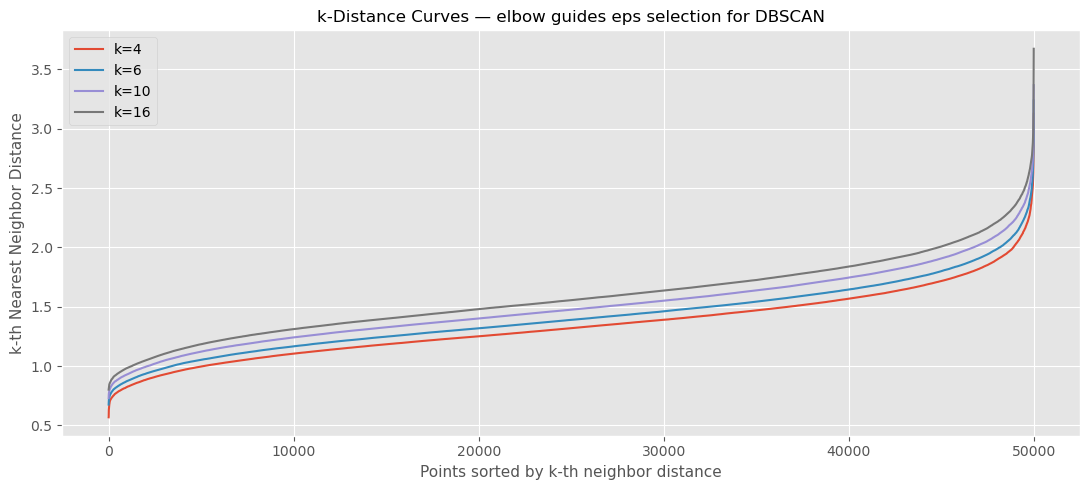

k-Distance quantile table:
       q50     q75     q90     q95     q99
k                                         
4   1.3195  1.5145  1.7167  1.8513  2.1498
6   1.3895  1.5912  1.7997  1.9411  2.2486
10  1.4752  1.6878  1.9068  2.0540  2.3707
16  1.5554  1.7795  2.0072  2.1628  2.4936


In [21]:
subset_sizes = [10000, 20000, 50000]


all_kdist_results = {}

for size in subset_sizes:
    print(f"\n===== SUBSET SIZE: {size} =====")

    X_scaled, y_sub, meta_sub = build_stratified_subset(
        X_full, y_full, meta_full,
        selected_phonemes=SELECTED_PHONEMES,
        subset_size=size,
        random_seed=RANDOM_SEED,
        plot_dist=True   # avoid too many plots
    )

    # compute k-distance
    kdist_df = plot_k_distance_curves(X_scaled)

    print('k-Distance quantile table:')
    print(kdist_df)

    # store results
    all_kdist_results[size] = kdist_df

< 2.0 → very dense core points
2.0 – 2.3 → cluster interior
2.3 – 2.5 → boundary region
> 2.5 → sparse / likely noise

In [22]:
def evaluate_clustering(y_true, labels, method_name):
    '''
    Compute a full suite of clustering metrics.

    Noise points (label == -1) are included in NMI/AMI/ARI (treated as a
    separate "noise class", which penalises excessive noise). Homogeneity,
    completeness, V-measure, and purity are computed on clustered points only.

    Parameters
    ----------
    y_true      : np.ndarray — true phoneme labels
    labels      : np.ndarray — cluster assignments; -1 = noise
    method_name : str

    Returns
    -------
    dict with keys: method, n_clusters, noise_fraction, coverage,
                    nmi, ami, ari, homogeneity, completeness, v_measure,
                    clustered_purity
    '''
    n = len(labels)
    n_clusters = len(set(labels) - {-1})
    n_noise = (labels == -1).sum()
    noise_frac = n_noise / n

    nmi = normalized_mutual_info_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels)
    ari = adjusted_rand_score(y_true, labels)

    cmask = labels >= 0
    if cmask.sum() > 1:
        hom = homogeneity_score(y_true[cmask], labels[cmask])
        com = completeness_score(y_true[cmask], labels[cmask])
        vms = v_measure_score(y_true[cmask], labels[cmask])
        purity_sum = sum(
            Counter(y_true[labels == cid]).most_common(1)[0][1]
            for cid in set(labels[cmask])
        )
        cl_purity = purity_sum / cmask.sum()
    else:
        hom = com = vms = cl_purity = 0.0

    return {
        'method': method_name,
        'n_clusters': n_clusters,
        'noise_fraction': round(noise_frac, 4),
        'coverage': round(1 - noise_frac, 4),
        'nmi': round(nmi, 4),
        'ami': round(ami, 4),
        'ari': round(ari, 4),
        'homogeneity': round(hom, 4),
        'completeness': round(com, 4),
        'v_measure': round(vms, 4),
        'clustered_purity': round(cl_purity, 4),
    }


def cluster_purity_table(y_true, labels):
    '''Per-cluster breakdown: size, majority phone, purity, top-3 phones.'''
    rows = []
    for cid in sorted(set(labels) - {-1}):
        mask = labels == cid
        cnt = Counter(y_true[mask])
        top3 = cnt.most_common(3)
        maj, maj_cnt = top3[0]
        rows.append({
            'cluster': cid,
            'size': int(mask.sum()),
            'majority_phone': maj,
            'purity': round(maj_cnt / mask.sum(), 3),
            'top_3_phones': ', '.join(f'{p}({c})' for p, c in top3),
        })
    noise_cnt = (labels == -1).sum()
    rows.append({'cluster': 'noise(-1)', 'size': int(noise_cnt),
                 'majority_phone': '-', 'purity': 1.0, 'top_3_phones': '-'})
    return pd.DataFrame(rows)

def dbscan_sweep(X, y, eps_grid, min_samples_grid, target_clusters=5,
                 algorithm='ball_tree'):
    '''
    Grid search over (eps, min_samples) for DBSCAN.

    Parameters
    ----------
    X                : np.ndarray — scaled features (already standardized)
    y                : np.ndarray — true phoneme labels
    eps_grid         : list of float
    min_samples_grid : list of int
    target_clusters  : int — used to compute cluster_gap = |n_clusters - target|
    algorithm        : str — 'ball_tree' avoids OpenMP shared-memory issues

    Returns
    -------
    pd.DataFrame — one row per (eps, min_samples) combination
    '''
    rows = []
    total = len(eps_grid) * len(min_samples_grid)
    done = 0
    for ms in min_samples_grid:
        for eps in eps_grid:
            lbl = DBSCAN(eps=eps, min_samples=ms,
                         algorithm=algorithm, n_jobs=-1).fit_predict(X)
            m = evaluate_clustering(y, lbl, f'eps={eps}_ms={ms}')
            m['eps'] = eps
            m['min_samples'] = ms
            m['cluster_gap'] = abs(m['n_clusters'] - target_clusters)
            rows.append(m)
            done += 1
            if done % 4 == 0 or done == total:
                print(f'  [{done:2d}/{total}] eps={eps:.2f} ms={ms:2d}  '
                      f'clusters={m["n_clusters"]:2d}  '
                      f'nmi={m["nmi"]:.3f}  cov={m["coverage"]:.1%}')
    return pd.DataFrame(rows)


def plot_sweep_heatmap(sweep_df, metric='nmi', target_clusters=5, title=None, ax=None):
    '''
    2D heatmap: eps (x-axis) vs min_samples (y-axis) colored by a metric.
    Cells are annotated with the number of clusters found.

    Parameters
    ----------
    sweep_df        : pd.DataFrame — output of dbscan_sweep
    metric          : str — column name to use as color
    target_clusters : int
    ax              : matplotlib Axes or None
    '''
    pivot_val  = sweep_df.pivot(index='min_samples', columns='eps', values=metric)
    pivot_clus = sweep_df.pivot(index='min_samples', columns='eps', values='n_clusters')
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(11, 5))
    sns.heatmap(pivot_val, annot=pivot_clus.astype(str), fmt='s',
                cmap='YlOrRd', ax=ax, linewidths=0.3,
                cbar_kws={'label': metric})
    ax.set_title(title or f'DBSCAN sweep — {metric} (cell annotations = n_clusters)', fontsize=11)
    ax.set_xlabel('eps'); ax.set_ylabel('min_samples')
    if standalone:
        plt.tight_layout(); plt.show()


 DATASET SIZE: 10000
Subset: 10,000 frames (2000 per class)
Mean (scaled): [-0. -0.  0. -0. -0. -0.  0. -0.  0. -0.  0.  0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
DBSCAN sweep: 9 eps x 5 min_samples = 45 configs
  [ 4/45] eps=1.90 ms= 5  clusters= 4  nmi=0.026  cov=92.4%
  [ 8/45] eps=2.30 ms= 5  clusters= 1  nmi=0.003  cov=99.1%
  [12/45] eps=1.80 ms= 8  clusters= 4  nmi=0.063  cov=83.5%
  [16/45] eps=2.20 ms= 8  clusters= 1  nmi=0.008  cov=98.1%
  [20/45] eps=1.70 ms=10  clusters= 4  nmi=0.106  cov=71.9%
  [24/45] eps=2.10 ms=10  clusters= 1  nmi=0.017  cov=96.1%
  [28/45] eps=1.60 ms=15  clusters= 2  nmi=0.166  cov=50.7%
  [32/45] eps=2.00 ms=15  clusters= 1  nmi=0.044  cov=90.9%
  [36/45] eps=2.40 ms=15  clusters= 1  nmi=0.004  cov=99.2%
  [40/45] eps=1.90 ms=20  clusters= 1  nmi=0.083  cov=81.5%
  [44/45] eps=2.30 ms=20  clusters= 1  nmi=0.013  cov=97.9%
  [45/45] eps=2.40 ms=20  clusters= 1  nmi=0.009  cov=98.8%

Top configs:


,min_samples,eps,n_clusters,coverage,nmi,ami,ari,homogeneity,completeness,v_measure,clustered_purity
9,8,1.6,5,0.6326,0.1086,0.1077,0.0780,0.0106,0.3116,0.0206,0.3022
3,5,1.9,4,0.9239,0.0264,0.0255,0.0038,0.0013,0.1933,0.0025,0.2155
2,5,1.8,4,0.8729,0.0448,0.0439,0.0120,0.0013,0.1863,0.0025,0.2266
11,8,1.8,4,0.8355,0.0632,0.0624,0.0230,0.0014,0.1980,0.0028,0.2361
19,10,1.7,4,0.7194,0.1064,0.1057,0.0628,0.0109,0.3531,0.0212,0.2758
28,15,1.7,4,0.6445,0.1395,0.1389,0.0983,0.0142,0.4099,0.0275,0.3033
1,5,1.7,7,0.8005,0.0665,0.0650,0.0280,0.0037,0.1898,0.0073,0.2467
10,8,1.7,3,0.7469,0.0873,0.0867,0.0483,0.0020,0.2388,0.0039,0.2611


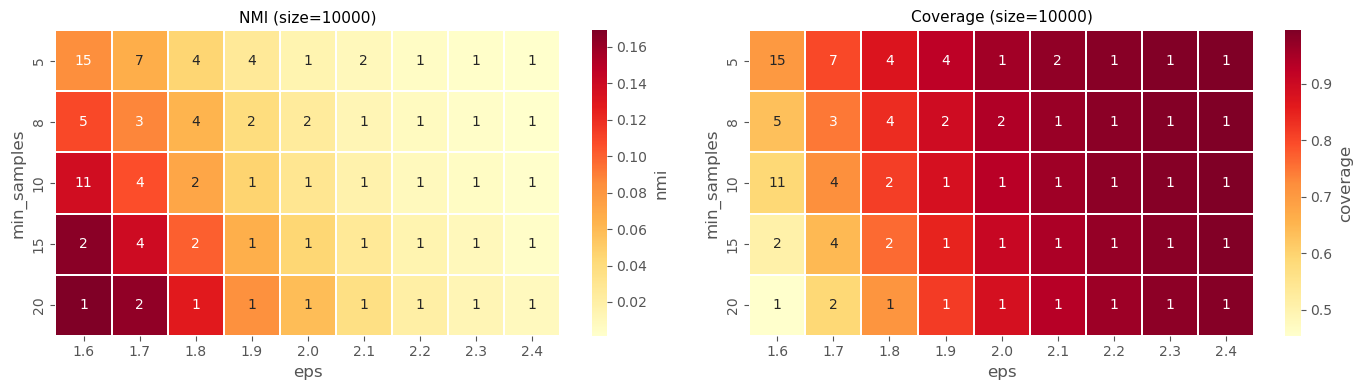


 DATASET SIZE: 50000
Subset: 50,000 frames (10000 per class)
Mean (scaled): [-0. -0. -0. -0. -0.  0. -0.  0.  0.  0. -0.  0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
DBSCAN sweep: 9 eps x 5 min_samples = 45 configs
  [ 4/45] eps=1.90 ms= 5  clusters= 3  nmi=0.005  cov=98.9%
  [ 8/45] eps=2.30 ms= 5  clusters= 1  nmi=0.000  cov=100.0%
  [12/45] eps=1.80 ms= 8  clusters= 3  nmi=0.013  cov=96.9%
  [16/45] eps=2.20 ms= 8  clusters= 1  nmi=0.001  cov=99.8%
  [20/45] eps=1.70 ms=10  clusters= 3  nmi=0.028  cov=93.3%
  [24/45] eps=2.10 ms=10  clusters= 1  nmi=0.002  cov=99.5%
  [28/45] eps=1.60 ms=15  clusters= 2  nmi=0.061  cov=84.3%
  [32/45] eps=2.00 ms=15  clusters= 1  nmi=0.007  cov=98.7%
  [36/45] eps=2.40 ms=15  clusters= 1  nmi=0.001  cov=99.9%
  [40/45] eps=1.90 ms=20  clusters= 1  nmi=0.015  cov=96.9%
  [44/45] eps=2.30 ms=20  clusters= 1  nmi=0.001  cov=99.8%
  [45/45] eps=2.40 ms=20  clusters= 1  nmi=0.001  cov=99.9%

Top configs:


,min_samples,eps,n_clusters,coverage,nmi,ami,ari,homogeneity,completeness,v_measure,clustered_purity
20,10,1.8,4,0.9641,0.0157,0.0155,0.0011,0.0004,0.1583,0.0009,0.2072
18,10,1.6,6,0.8809,0.0445,0.0442,0.0111,0.0011,0.1889,0.0023,0.2249
3,5,1.9,3,0.9888,0.0049,0.0047,0.0001,0.0002,0.1562,0.0003,0.2022
11,8,1.8,3,0.9690,0.0132,0.0131,0.0007,0.0003,0.1705,0.0006,0.2062
10,8,1.7,3,0.9424,0.0230,0.0228,0.0026,0.0004,0.1704,0.0007,0.2113
19,10,1.7,3,0.9333,0.0276,0.0274,0.0037,0.0003,0.1689,0.0006,0.2132
4,5,2.0,2,0.9940,0.0027,0.0026,0.0000,0.0001,0.1577,0.0002,0.2012
21,10,1.9,2,0.9810,0.0092,0.0091,0.0003,0.0002,0.1692,0.0003,0.2037


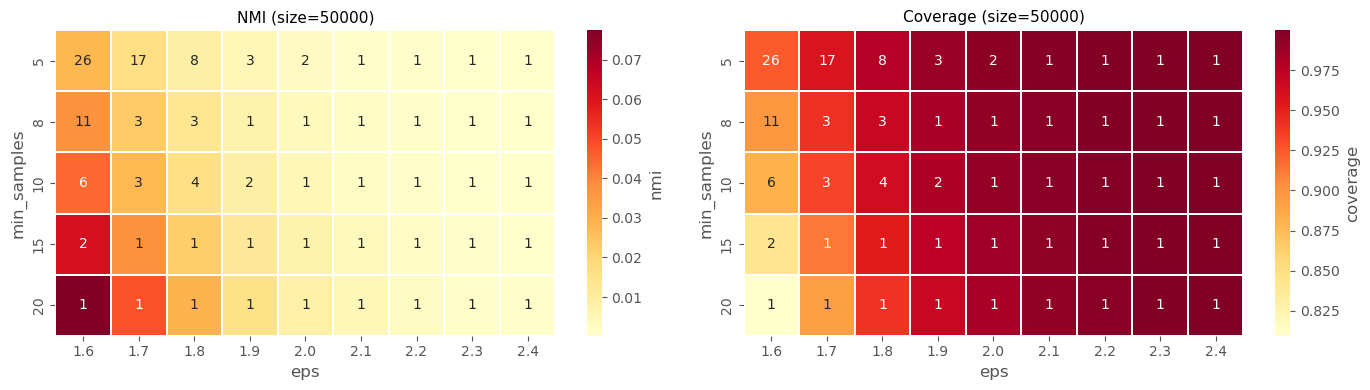

In [23]:
subset_sizes = [10000, 50000]
eps_grid = [round(v, 2) for v in np.arange(1.6, 2.5, 0.1)]
min_samples_grid = [5, 8, 10, 15, 20]

all_results = {} # gives the sweep_df

for size in subset_sizes:
    print(f"\n==============================")
    print(f" DATASET SIZE: {size}")
    print(f"==============================")

    X_scaled, y_sub, meta_sub = build_stratified_subset(
        X_full, y_full, meta_full,
        selected_phonemes=SELECTED_PHONEMES,
        subset_size=size,
        random_seed=RANDOM_SEED,
        plot_dist=False
    )

    print(f'DBSCAN sweep: {len(eps_grid)} eps x {len(min_samples_grid)} min_samples '
          f'= {len(eps_grid)*len(min_samples_grid)} configs')

    sweep_df = dbscan_sweep(
        X_scaled, y_sub,
        eps_grid,
        min_samples_grid,
        TARGET_CLUSTERS
    )

    all_results[size] = sweep_df

    print('\nTop configs:')
    display(
        sweep_df.sort_values(['cluster_gap', 'noise_fraction'])
        [['min_samples','eps','n_clusters','coverage','nmi','ami','ari',
          'homogeneity','completeness','v_measure','clustered_purity']]
        .head(8)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_sweep_heatmap(
        sweep_df,
        metric='nmi',
        target_clusters=TARGET_CLUSTERS,
        title=f'NMI (size={size})',
        ax=axes[0]
    )

    plot_sweep_heatmap(
        sweep_df,
        metric='coverage',
        target_clusters=TARGET_CLUSTERS,
        title=f'Coverage (size={size})',
        ax=axes[1]
    )

    plt.tight_layout()
    plt.show()


 FINAL EVAL — SIZE: 10000
Subset: 10,000 frames (2000 per class)
Mean (scaled): [-0. -0.  0. -0. -0. -0.  0. -0.  0. -0.  0.  0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Best config with exact cluster match:
  eps=1.6, min_samples=8

Metrics:
  method                : DBSCAN_size_10000
  n_clusters            : 5
  noise_fraction        : 0.3674
  coverage              : 0.6326
  nmi                   : 0.1086
  ami                   : 0.1077
  ari                   : 0.078
  homogeneity           : 0.0106
  completeness          : 0.3116
  v_measure             : 0.0206
  clustered_purity      : 0.3022

Cluster purity table:


,cluster,size,majority_phone,purity,top_3_phones
0,0,6279,s,0.298,"s(1869), iy(1416), ih(1383)"
1,1,6,n,0.833,"n(5), s(1)"
2,2,26,aa,1.000,aa(26)
3,3,8,aa,0.625,"aa(5), n(3)"
4,4,7,aa,1.000,aa(7)
5,noise(-1),3674,-,1.000,-


t-SNE computed: (5000, 2), perplexity=30.0


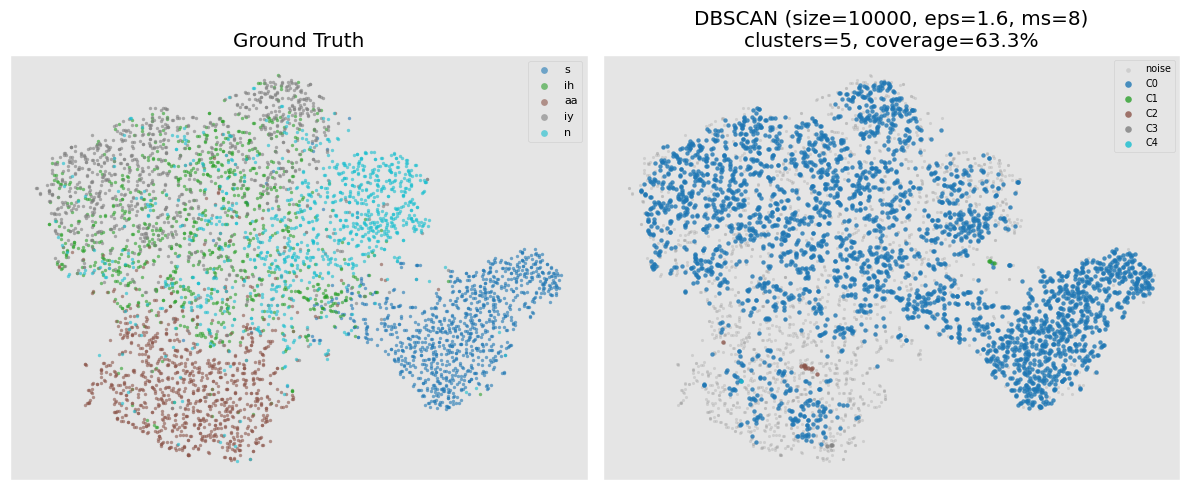


 FINAL EVAL — SIZE: 50000
Subset: 50,000 frames (10000 per class)
Mean (scaled): [-0. -0. -0. -0. -0.  0. -0.  0.  0.  0. -0.  0.]
Std  (scaled): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
No exact cluster match — using closest:
  eps=1.6, min_samples=10

Metrics:
  method                : DBSCAN_size_50000
  n_clusters            : 6
  noise_fraction        : 0.1191
  coverage              : 0.8809
  nmi                   : 0.0445
  ami                   : 0.0442
  ari                   : 0.0111
  homogeneity           : 0.0011
  completeness          : 0.1889
  v_measure             : 0.0023
  clustered_purity      : 0.2249

Cluster purity table:


,cluster,size,majority_phone,purity,top_3_phones
0,0,44000,s,0.224,"s(9861), iy(9302), ih(9111)"
1,1,11,n,1.000,n(11)
2,2,4,aa,1.000,aa(4)
3,3,8,aa,1.000,aa(8)
4,4,11,aa,1.000,aa(11)
5,5,11,aa,1.000,aa(11)
6,noise(-1),5955,-,1.000,-


t-SNE computed: (5000, 2), perplexity=30.0


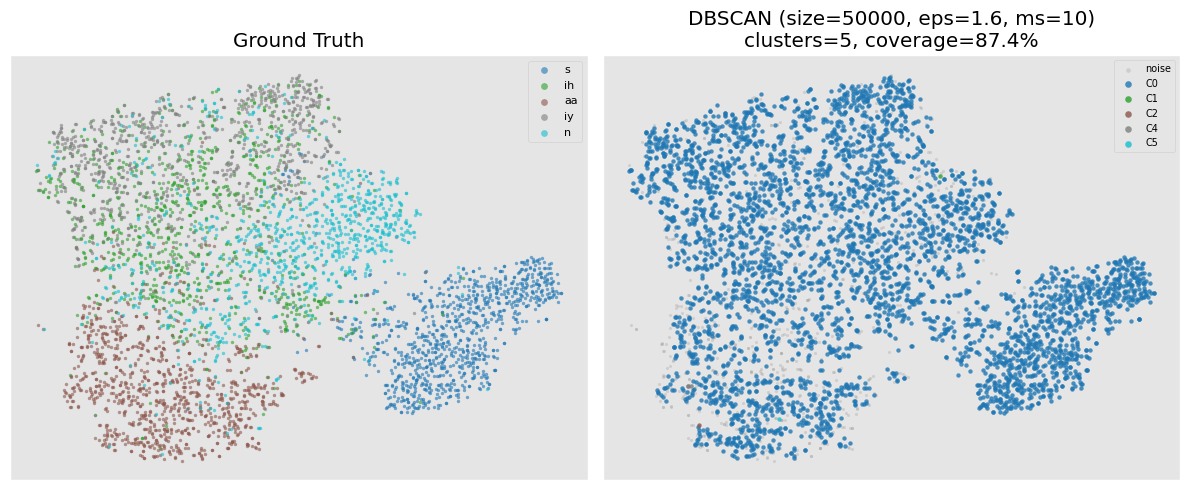

In [26]:
final_outputs = {}

for size, sweep_df in all_results.items():
    print(f"\n==============================")
    print(f" FINAL EVAL — SIZE: {size}")
    print(f"==============================")


    X_scaled, y_sub, meta_sub = build_stratified_subset(
        X_full, y_full, meta_full,
        selected_phonemes=SELECTED_PHONEMES,
        subset_size=size,
        random_seed=RANDOM_SEED,
        plot_dist=False
    )


    best5 = sweep_df[sweep_df['cluster_gap'] == 0].sort_values('nmi', ascending=False)

    if len(best5) > 0:
        best_row = best5.iloc[0]
        print('Best config with exact cluster match:')
    else:
        best_row = sweep_df.sort_values(
            ['cluster_gap', 'nmi'],
            ascending=[True, False]
        ).iloc[0]
        print('No exact cluster match — using closest:')

    BEST_EPS = best_row['eps']
    BEST_MS  = int(best_row['min_samples'])

    print(f'  eps={BEST_EPS}, min_samples={BEST_MS}')


    labels = DBSCAN(
        eps=BEST_EPS,
        min_samples=BEST_MS,
        algorithm='ball_tree',
        n_jobs=-1
    ).fit_predict(X_scaled)


    result = evaluate_clustering(y_sub, labels, f'DBSCAN_size_{size}')

    print('\nMetrics:')
    for k, v in result.items():
        print(f'  {k:22s}: {v}')

    print('\nCluster purity table:')
    display(cluster_purity_table(y_sub, labels))


    embedding, vis_idx = compute_tsne_embedding(
        X_scaled,
        tsne_size=5000,   # you can vary this
        seed=RANDOM_SEED
    )

    y_vis = y_sub[vis_idx]


    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_tsne_clusters(
        embedding,
        labels[vis_idx],
        y_vis,
        selected_phonemes=SELECTED_PHONEMES,
        method_name=f'DBSCAN (size={size}, eps={BEST_EPS}, ms={BEST_MS})',
        axes=axes
    )

    plt.tight_layout()
    plt.show()

    # ---------- STORE ----------
    final_outputs[size] = {
        'best_eps': BEST_EPS,
        'best_min_samples': BEST_MS,
        'metrics': result,
        'labels': labels
    }